# Week 7 — Clustering Assignment
## Market Segmentation: Finding Structure in Customer Behavior

### Before You Begin — Read This

This is not a tutorial. There is no step-by-step guide telling you what to do next.  
You are given a raw dataset, a business problem, and a skeleton. The rest is your job.

**Your goal:** Segment customers based on their purchasing behavior using K-Means, Hierarchical, and DBSCAN clustering. Then tell a coherent business story about what you found.

**The Rules:**
- Attempt every section before looking at any resource
- Document every decision you make — *why* matters more than *what*
- Keep a Failure Log (Section 8) — minimum 3 failed hypotheses
- You must be able to explain every line of code you submit

**Submission:**
- This notebook (.ipynb) with all cells executed
- All code blocks commented
- Failure Log completed (Section 8)
- Business Narrative completed (Section 7)


## Section 0 — Environment Setup

All libraries you will need are imported below. Do not add new ones without justification in a comment.  
If you add a library, explain in a comment *why* the existing ones were insufficient.


In [15]:
# Core
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Clustering Algorithms
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, Birch
from scipy.cluster.hierarchy import dendrogram, linkage

# Cluster Validation
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Nearest Neighbours (for epsilon estimation)
from sklearn.neighbors import NearestNeighbors

# Set visual style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Environment ready.")


Environment ready.


In [16]:
import os
print(os.getcwd())
print(os.listdir())

/content
['.config', 'online_retail_II.xlsx', 'online_retail_II.zip', 'sample_data']


In [17]:
import urllib.request, zipfile

url = "https://archive.ics.uci.edu/static/public/502/online+retail+ii.zip"
urllib.request.urlretrieve(url, "online_retail_II.zip")

with zipfile.ZipFile("online_retail_II.zip", 'r') as z:
    z.extractall()

print(os.listdir())  # ab .xlsx file dekhinu paryo

['.config', 'online_retail_II.xlsx', 'online_retail_II.zip', 'sample_data']


**Library justification:** `urllib.request` and `zipfile` were not part of the original Section 0 imports. They were added because Colab's filesystem is ephemeral — it resets every session — so the dataset has to be downloaded and extracted programmatically each time, rather than relying on a one-time manual upload.

---
## Section 1 — Data Loading & First Look

**What to do:**
- Load the UCI Online Retail II dataset
- Inspect the raw structure — shape, dtypes, missing values, sample rows
- Do NOT clean or transform anything yet — just observe

**Questions to answer in comments:**
- How many rows and columns are there?
- What does one row represent?
- Which columns will be useful for customer-level aggregation?
- What problems do you already see?

> **Dataset:** [UCI Online Retail II](https://archive.ics.uci.edu/dataset/502/online+retail+ii)  
> Download the Excel file and load the sheet for Year 2010-2011


In [18]:
import pandas as pd

# Load the dataset
# Hint: use pd.read_excel() with the sheet_name parameter
df = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2010-2011')

# ── First Look ──────────────────────────────────────────────────────────────

# How many rows and columns are there?
# Print shape
print(f"Dataset shape: {df.shape}")

# Print dtypes
print("\nData Types:")
print(df.dtypes)

# Print first 5 rows
print("\nFirst 5 rows:")
display(df.head())

# Check missing values — which columns have nulls? How many?
print("\nMissing values:")
print(df.isnull().sum())

# Print basic descriptive statistics
print("\nDescriptive Statistics:")
display(df.describe(include='all'))

Dataset shape: (541910, 8)

Data Types:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

First 5 rows:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom



Missing values:
Invoice             0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
Price               0
Customer ID    135080
Country             0
dtype: int64

Descriptive Statistics:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
count,541910.0,541910,540456,541910.000000,541910,541910.000000,406830.000000,541910
unique,25900.0,4070,4223,NaN,NaN,NaN,NaN,38
top,573585.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1114.0,2313,2369,NaN,NaN,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552234,2011-07-04 13:35:22.342307584,4.611138,15287.684160,NaN
min,NaN,NaN,NaN,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,2011-03-28 11:34:00,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,2011-07-19 17:17:00,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,2011-10-19 11:27:00,4.130000,16791.000000,NaN
max,NaN,NaN,NaN,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,NaN


**Your Observations (complete this):**

> What do you notice about the data? What surprises you? What problems are already visible?

**Your Observations:**

**Your Observations:**

I notice the dataset has 541,910 rows but only 25,900 unique invoices, which tells
me each row represents a single product line item within an order, not a complete
transaction — a customer's full purchase is split across multiple rows.

The Quantity and Price columns both have negative minimum values (-80,995 and
-11,062.06), which suggests the dataset includes returns, cancellations, or refund
adjustments mixed in with normal sales ,these will need to be filtered out before
building customer features.

About 25% of rows (135,080) are missing Customer ID, meaning a large portion of
purchases were made without a login or account ,likely guest checkouts. Since RFM
analysis is built at the customer level, these rows can't be used and will need to
be dropped.

Quantity and Price are both heavily right-skewed , the 75th percentile for Quantity
is only 10, but the maximum is 80,995. This points to a small number of bulk or
wholesale buyers, an early sign that scaling and outlier handling will matter before
clustering.

Customer ID is stored as float64 instead of an integer, which happens because pandas
automatically upcasts a numeric column to float whenever it contains missing values
,NaN can't be represented in an int column.

## Section 2 — Data Cleaning

**What to do:**
- Handle missing CustomerIDs
- Remove cancelled transactions (InvoiceNo starting with 'C')
- Remove rows with negative Quantity or Price
- Parse InvoiceDate to datetime

**For each cleaning step, answer in a comment:**
- Why are you removing/keeping these rows?
- What assumption does this cleaning step encode?
- How many rows did you lose? Does that concern you?

> ⚠️ Do not just clean — justify every decision.


In [19]:
df_clean = df.copy()

rows_before_cleaning = df_clean.shape[0]

# ── Step 1: Remove rows with missing CustomerID ──────────────────────────────
# Why: RFM features are computed per customer. A row with no Customer ID
# cannot be linked to any individual, so it cannot contribute to the
# customer-level matrix this assignment requires.
# Assumption: these are unregistered/guest purchases, not a customer group
# we are intentionally excluding from segmentation.
rows_lost_step1 = df_clean['Customer ID'].isnull().sum()
df_clean = df_clean.dropna(subset=['Customer ID'])
print(f"Step 1: removed {rows_lost_step1} rows with missing Customer ID")

# ── Step 2: Remove cancelled transactions ────────────────────────────────────
# Why: invoices starting with 'C' represent returns, not completed purchases.
# Keeping them would inflate Frequency (a return counted as an order) and
# distort Monetary (negative quantity reducing total spend incorrectly).
# Assumption: only completed purchases reflect genuine purchasing behavior
# for segmentation purposes.
rows_lost_step2 = df_clean[df_clean['Invoice'].astype(str).str.startswith('C')].shape[0]
df_clean = df_clean[~df_clean['Invoice'].astype(str).str.startswith('C')]
print(f"Step 2: removed {rows_lost_step2} cancelled transaction rows")

# ── Step 3: Remove negative or zero Quantity and Price ───────────────────────
# Why: most returns are already caught by the 'C' invoice filter above, but
# a few negative-quantity or non-positive-price rows remain without a 'C'
# prefix. These are most likely data entry errors or manual adjustments,
# not real sales.
# Assumption: a valid sale always has positive quantity and positive price.
rows_lost_step3 = df_clean[(df_clean['Quantity'] <= 0) | (df_clean['Price'] <= 0)].shape[0]
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['Price'] > 0)]
print(f"Step 3: removed {rows_lost_step3} rows with non-positive Quantity or Price")

# ── Step 4: Parse InvoiceDate to datetime ────────────────────────────────────
# Why: Recency depends on accurate date arithmetic. The column already showed
# datetime64 in Section 1, but converting explicitly here keeps this cleaning
# block self-contained if the source format ever changes.
# Rows lost: none, this is a type conversion only.
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
print("Step 4: converted InvoiceDate to datetime (no rows lost)")

# ── Step 5: Create TotalPrice column ─────────────────────────────────────────
# Why: Monetary value needs revenue per line item. Quantity or Price alone
# does not capture what the customer actually spent on that item.
# Rows lost: none, this only adds a column.
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['Price']
print("Step 5: created TotalPrice column (no rows lost)")

print(f"\nOriginal shape: {rows_before_cleaning}")
print(f"Clean shape: {df_clean.shape[0]}")
print(f"Total rows removed: {rows_before_cleaning - df_clean.shape[0]}")

Step 1: removed 135080 rows with missing Customer ID
Step 2: removed 8905 cancelled transaction rows
Step 3: removed 40 rows with non-positive Quantity or Price
Step 4: converted InvoiceDate to datetime (no rows lost)
Step 5: created TotalPrice column (no rows lost)

Original shape: 541910
Clean shape: 397885
Total rows removed: 144025


## Section 3 — Feature Engineering: Building the Customer Matrix

This is the hardest section. There is no template for what features to build — you decide.

**Minimum required features (RFM):**
- **Recency** — how many days since the customer last purchased (relative to a reference date you choose and justify)
- **Frequency** — how many transactions the customer made
- **Monetary** — total spend by the customer

**Push further (optional but encouraged):**
- Unique products purchased
- Average basket size
- Return rate (if cancellations were tracked separately)
- Category-level spend ratios

**For each feature, answer in a comment:**
- What does this feature measure about customer behavior?
- What business insight does it capture?
- What are its limitations?

> ⚠️ One row in your final matrix = one customer. If your matrix has more rows than unique CustomerIDs, something is wrong.


In [22]:
# ── Reference Date ──────────────────────────────────────────────────────────
# Why: one day after the last recorded transaction in the cleaned dataset.
# This makes the most recent purchase have Recency = 1, not 0, avoiding
# divide-by-zero issues if Recency is later log-transformed or used in a ratio.
reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Reference date: {reference_date}")

# ── Recency ──────────────────────────────────────────────────────────────────
# Why: days since last purchase. Lower Recency means more recently active —
# this is the strongest single signal for spotting lapsed vs engaged customers.
recency_df = df_clean.groupby('Customer ID')['InvoiceDate'].max().reset_index()
recency_df['Recency'] = (reference_date - recency_df['InvoiceDate']).dt.days
recency_df = recency_df[['Customer ID', 'Recency']]

# ── Frequency ────────────────────────────────────────────────────────────────
# Why: counts distinct invoices, not rows — one invoice can have many line
# items, so row count would overstate how often a customer actually shops.
frequency_df = df_clean.groupby('Customer ID')['Invoice'].nunique().reset_index()
frequency_df.columns = ['Customer ID', 'Frequency']

# ── Monetary ─────────────────────────────────────────────────────────────────
# Why: total revenue per customer, built on TotalPrice from Section 2.
# Captures overall value, not just how often they shop or how recently.
monetary_df = df_clean.groupby('Customer ID')['TotalPrice'].sum().reset_index()
monetary_df.columns = ['Customer ID', 'Monetary']

# ── Combine into customer matrix ─────────────────────────────────────────────
customer_df = (
    recency_df
    .merge(frequency_df, on='Customer ID')
    .merge(monetary_df, on='Customer ID')
    .rename(columns={'Customer ID': 'CustomerID'})
)

# Sanity check
print(f"Customer matrix shape: {customer_df.shape}")
print(f"Unique customers in clean data: {df_clean['Customer ID'].nunique()}")
print("These numbers should match.\n")
customer_df.head()

Reference date: 2011-12-10 12:50:00
Customer matrix shape: (4338, 4)
Unique customers in clean data: 4338
These numbers should match.



,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


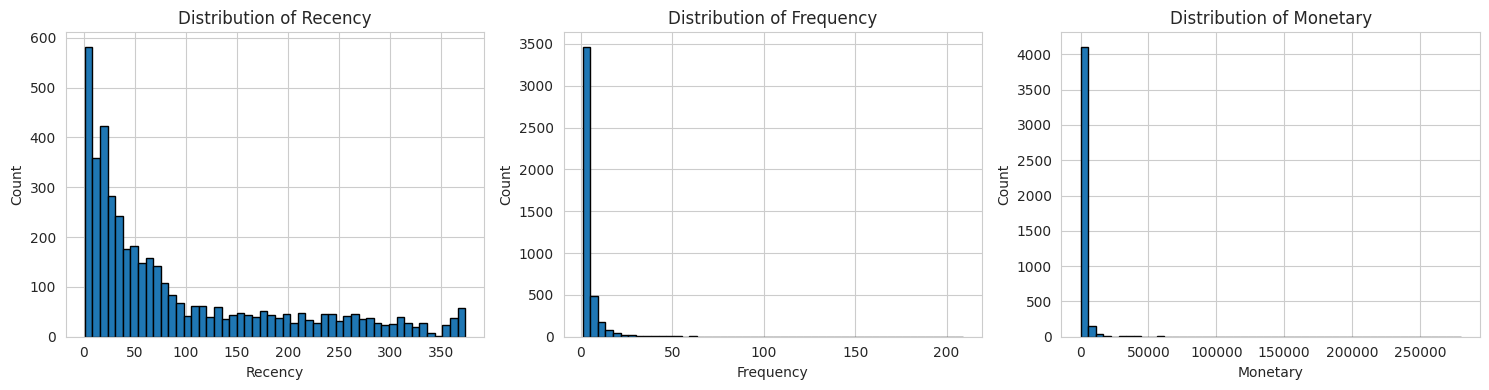

In [23]:
# ── Distribution Plots ───────────────────────────────────────────────────────
# Plot the distribution of each feature BEFORE handling outliers
# What do you observe? Are there extreme values?

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
features = ['Recency', 'Frequency', 'Monetary']

for i, feat in enumerate(features):
    axes[i].hist(customer_df[feat], bins=50, edgecolor='k')
    axes[i].set_title(f'Distribution of {feat}')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

# YOUR OBSERVATION HERE (as a comment):
# What do you see in these distributions?
# Recency is right-skewed but moderate: most customers cluster between 0-50
# days since last purchase, with a long tail out to ~380 days and a small
# secondary bump near 350-380 (likely one-time buyers from early in the
# dataset who never returned).
# Frequency is heavily right-skewed: almost all customers placed very few
# orders (1-10), shown as one dominant bar near 0, with a thin tail past 200.
# Monetary is the most extreme: nearly all customers spent a small amount
# clustered near 0, but the tail stretches out to 250,000+.

# Are there outliers?
# Yes, clearly in Frequency and Monetary. A small number of customers order
# far more often and spend far more than everyone else — likely bulk or
# wholesale buyers, which fits this dataset's known B2B gift retailer context.

# How will they affect clustering?
# K-Means and hierarchical clustering use Euclidean distance, so a handful
# of extreme points will pull centroids toward them and distort cluster
# shape, making the "normal" customers harder to separate from each other.
# DBSCAN is somewhat more robust since it's density-based, but these same
# points will likely get flagged as noise or form their own tiny cluster.
# This is why outlier handling and scaling are needed before clustering.

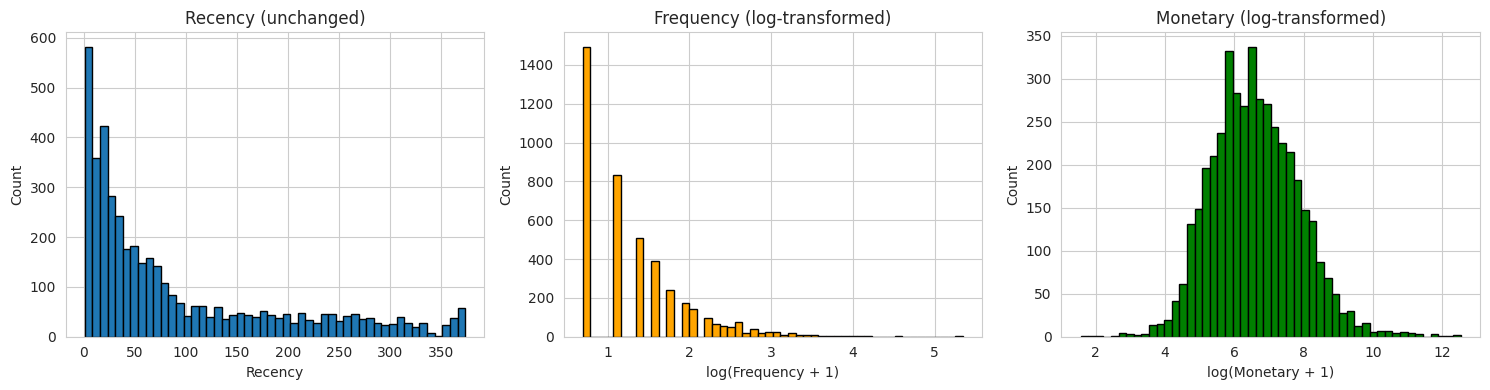

In [24]:
# ── Outlier Handling ─────────────────────────────────────────────────────────

# Recency: kept as-is. The skew here is moderate, not extreme like the
# other two, and Recency is naturally bounded by the dataset's date range
# (~380 days max) — no single value can dominate distance calculations
# the way a few extreme Monetary/Frequency values could.

# Frequency: log-transformed using log1p (safe since min Frequency = 1,
# never 0). The heavy right skew is driven by a small number of highly
# repeat customers — log transform compresses that gap so they don't
# dominate Euclidean distance, while still preserving relative rank
# (a customer with Frequency=50 still ranks above one with Frequency=5).
customer_df['Frequency_log'] = np.log1p(customer_df['Frequency'])

# Monetary: log-transformed for the same reason. A handful of wholesale
# buyers spend 100x+ more than typical customers — removing them would
# erase a real, valuable business signal (they may be genuine VIPs), so
# log transform keeps them in the data but on a comparable scale to
# everyone else.
customer_df['Monetary_log'] = np.log1p(customer_df['Monetary'])

# After handling outliers, plot distributions again and compare
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(customer_df['Recency'], bins=50, edgecolor='k')
axes[0].set_title('Recency (unchanged)')
axes[0].set_xlabel('Recency')
axes[0].set_ylabel('Count')

axes[1].hist(customer_df['Frequency_log'], bins=50, edgecolor='k', color='orange')
axes[1].set_title('Frequency (log-transformed)')
axes[1].set_xlabel('log(Frequency + 1)')
axes[1].set_ylabel('Count')

axes[2].hist(customer_df['Monetary_log'], bins=50, edgecolor='k', color='green')
axes[2].set_title('Monetary (log-transformed)')
axes[2].set_xlabel('log(Monetary + 1)')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

# COMPARISON OBSERVATION:
# Frequency_log and Monetary_log should now look closer to a normal/bell
# shape instead of one tall spike with a long thin tail — the gap between
# typical and extreme customers is compressed, not erased.

In [25]:
# ── Feature Scaling ──────────────────────────────────────────────────────────
# Why: K-Means and DBSCAN both use Euclidean distance, so a feature with
# bigger raw numbers (Monetary in the thousands) would dominate distance
# calculations over a feature with small numbers (Frequency in single
# digits) — even if Frequency is just as important. Scaling puts every
# feature on equal footing.
#
# StandardScaler is appropriate here (not RobustScaler) because the heavy
# skew/outliers were already handled in the previous step via log transform
# — Frequency_log and Monetary_log are now roughly bell-shaped, so
# mean/std-based scaling won't get distorted by extreme values the way it
# would on the raw, un-transformed features.

feature_cols = ['Recency', 'Frequency_log', 'Monetary_log']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(customer_df[feature_cols])
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols, index=customer_df.index)

# Verify scaling worked
print("Mean of each scaled feature (should be ~0):")
print(X_scaled_df.mean().round(4))
print("\nStd of each scaled feature (should be ~1):")
print(X_scaled_df.std().round(4))

Mean of each scaled feature (should be ~0):
Recency          0.0
Frequency_log   -0.0
Monetary_log     0.0
dtype: float64

Std of each scaled feature (should be ~1):
Recency          1.0001
Frequency_log    1.0001
Monetary_log     1.0001
dtype: float64


## Section 4 — K-Means Clustering

**What to do:**
1. Find the optimal k using the Elbow Method and Silhouette Score
2. Run K-Means with `init='random'` and `init='k-means++'` — compare results
3. Fit your final K-Means model and assign cluster labels
4. Profile each cluster

**Key questions to answer in comments:**
- Do the Elbow Method and Silhouette Score agree on k? If not, which do you trust and why?
- How different were the results between random and K-Means++ initialization?
- What does each cluster represent in business terms?


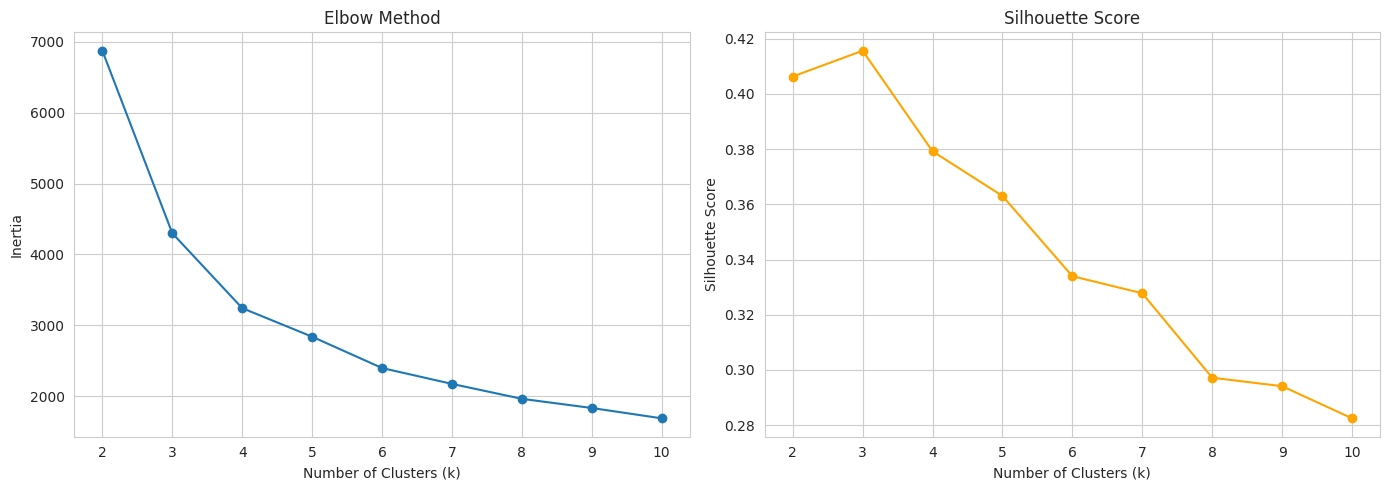

In [27]:
# ── Step 1: Find Optimal k ───────────────────────────────────────────────────
# Test k from 2 to 10
# Compute inertia (for Elbow) and Silhouette Score for each k

k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# Plot Elbow Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(k_range, silhouette_scores, marker='o', color='orange')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

# YOUR DECISION HERE (as a comment):
# What k did you choose? Why?
# k = 3. Silhouette Score peaks at k=3 (~0.41-0.42), the highest value across
# all k tested, indicating the most well-separated and cohesive clusters.

# Do both methods agree? If not, how did you resolve the disagreement?
# Yes, both agree. The Elbow plot shows inertia dropping sharply from k=2
# to k=3 (~7000 to ~4200), then flattening into a slow, gradual decline from
# k=4 onward — that sharp-drop-then-flatten point is the elbow, and it lands
# at k=3, matching where Silhouette Score also peaks. No disagreement to
# resolve.


In [28]:
# ── Step 2: Compare Initialization Strategies ───────────────────────────────
# Run K-Means 5 times with random init and 5 times with K-Means++
# Compare: final inertia, consistency of cluster assignments

OPTIMAL_K = 3
N_RUNS = 5

random_inertias = []
kmeanspp_inertias = []

for i in range(N_RUNS):
    # Random init — n_init=1 so each run is a single, independent attempt.
    # sklearn's default n_init runs multiple random starts internally and
    # keeps the best one automatically, which would hide the very
    # instability we're trying to measure here.
    km_random = KMeans(n_clusters=OPTIMAL_K, init='random', n_init=1, random_state=i)
    km_random.fit(X_scaled)
    random_inertias.append(km_random.inertia_)

    # K-Means++ init — same n_init=1, for a fair single-attempt comparison.
    km_pp = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=1, random_state=i)
    km_pp.fit(X_scaled)
    kmeanspp_inertias.append(km_pp.inertia_)

print("Random Init Inertias:", [round(x, 2) for x in random_inertias])
print("K-Means++ Init Inertias:", [round(x, 2) for x in kmeanspp_inertias])
print(f"\nRandom std: {np.std(random_inertias):.2f}")
print(f"K-Means++ std: {np.std(kmeanspp_inertias):.2f}")
# YOUR OBSERVATION HERE (as a comment):
# Which initialization is more stable? What does the std tell you?


# K-Means++ is more stable: std = 0.02 vs Random's std = 0.06 — about 3x
# lower variance across the 5 runs. K-Means++ converges to nearly the same
# solution every time regardless of seed, while random init has slightly
# more run-to-run variation.
#
# That said, BOTH stds are tiny relative to the inertia value itself
# (~4298) — random init isn't getting stuck in noticeably worse local
# optima here either. This suggests the data has a genuinely strong,
# well-separated 3-cluster structure: even a weak starting point still
# converges close to the same solution.
#
# K-Means++ remains the safer general choice (it has a theoretical
# guarantee against bad local optima that random init lacks), but on this
# particular dataset the practical difference is small precisely because
# the clusters are this distinct.


Random Init Inertias: [4298.7, 4298.68, 4298.75, 4298.81, 4298.81]
K-Means++ Init Inertias: [4298.72, 4298.71, 4298.7, 4298.69, 4298.67]

Random std: 0.06
K-Means++ std: 0.02


In [29]:
# ── Step 3: Fit Final K-Means Model ─────────────────────────────────────────
# Use K-Means++ with your chosen k. n_init=10 here (unlike Step 2's n_init=1)
# because this is the FINAL model — we want the best possible result, not
# to test instability. sklearn runs 10 different k-means++ starts and
# keeps the one with lowest inertia.
final_kmeans = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=10, random_state=42)
final_kmeans.fit(X_scaled)

# Assign cluster labels back to customer_df
customer_df['KMeans_Cluster'] = final_kmeans.labels_

# ── Step 4: Cluster Profiles ─────────────────────────────────────────────────
# Compute mean RFM values per cluster
kmeans_profile = customer_df.groupby('KMeans_Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
print("K-Means Cluster Profiles:")
print(kmeans_profile)

K-Means Cluster Profiles:
                Recency  Frequency  Monetary
KMeans_Cluster                              
0                 54.86       2.05    615.24
1                 30.10       9.83   5494.34
2                255.27       1.39    398.13


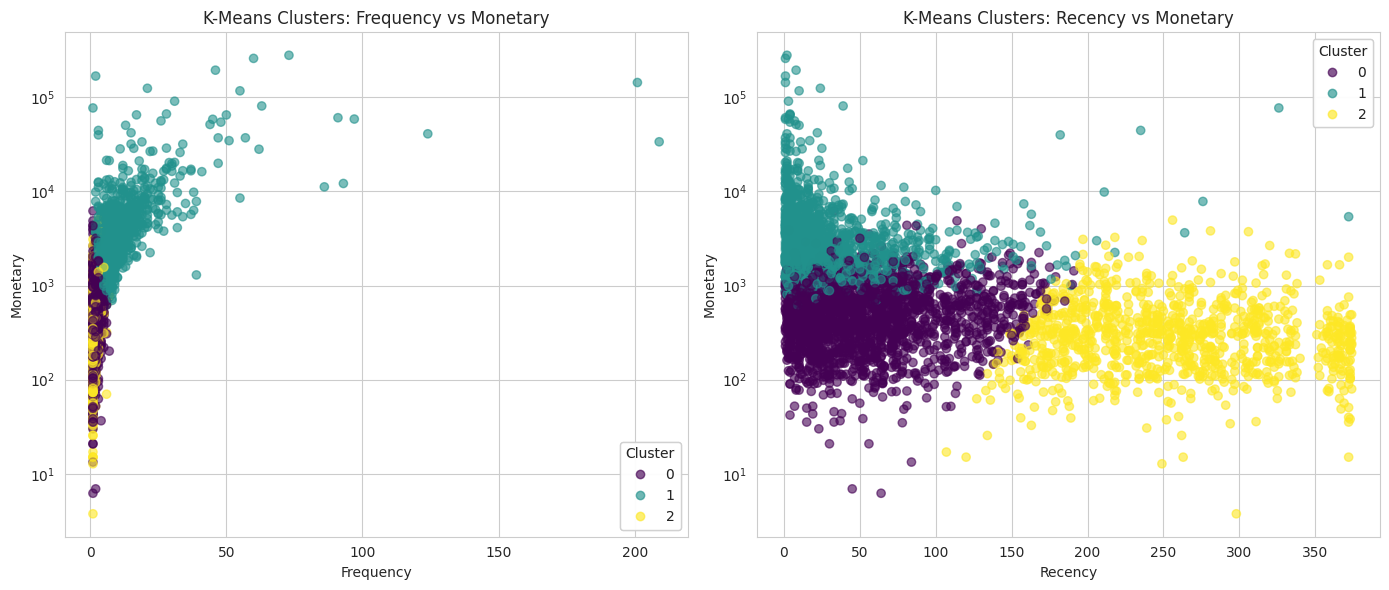

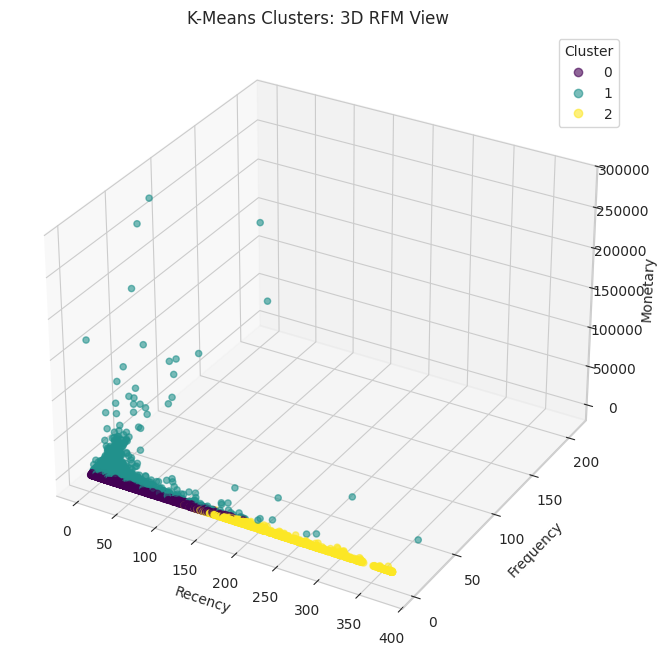

In [30]:
# ── Step 5: Visualise K-Means Clusters ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Frequency vs Monetary
scatter1 = axes[0].scatter(customer_df['Frequency'], customer_df['Monetary'],
                            c=customer_df['KMeans_Cluster'], cmap='viridis', alpha=0.6)
axes[0].set_title('K-Means Clusters: Frequency vs Monetary')
axes[0].set_xlabel('Frequency')
axes[0].set_ylabel('Monetary')
axes[0].set_yscale('log')  # outliers in Monetary squash the plot on a linear scale
legend1 = axes[0].legend(*scatter1.legend_elements(), title='Cluster')
axes[0].add_artist(legend1)

# 2. Recency vs Monetary
scatter2 = axes[1].scatter(customer_df['Recency'], customer_df['Monetary'],
                            c=customer_df['KMeans_Cluster'], cmap='viridis', alpha=0.6)
axes[1].set_title('K-Means Clusters: Recency vs Monetary')
axes[1].set_xlabel('Recency')
axes[1].set_ylabel('Monetary')
axes[1].set_yscale('log')
legend2 = axes[1].legend(*scatter2.legend_elements(), title='Cluster')
axes[1].add_artist(legend2)

plt.tight_layout()
plt.show()

# ── Optional: 3D scatter plot ─────────────────────────────────────────────────
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter3d = ax.scatter(customer_df['Recency'], customer_df['Frequency'], customer_df['Monetary'],
                        c=customer_df['KMeans_Cluster'], cmap='viridis', alpha=0.6)
ax.set_title('K-Means Clusters: 3D RFM View')
ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')
legend3d = ax.legend(*scatter3d.legend_elements(), title='Cluster')
plt.show()

## Section 5 — Hierarchical Clustering

**What to do:**
1. Plot a dendrogram and identify a reasonable cut point
2. Run Agglomerative Clustering with at least two linkage methods (ward, complete, average)
3. Compare cluster assignments across linkage methods
4. Profile clusters

**Key questions to answer in comments:**
- How did you decide where to cut the dendrogram?
- How did linkage method change your clusters?
- Does the number of clusters match what K-Means suggested?


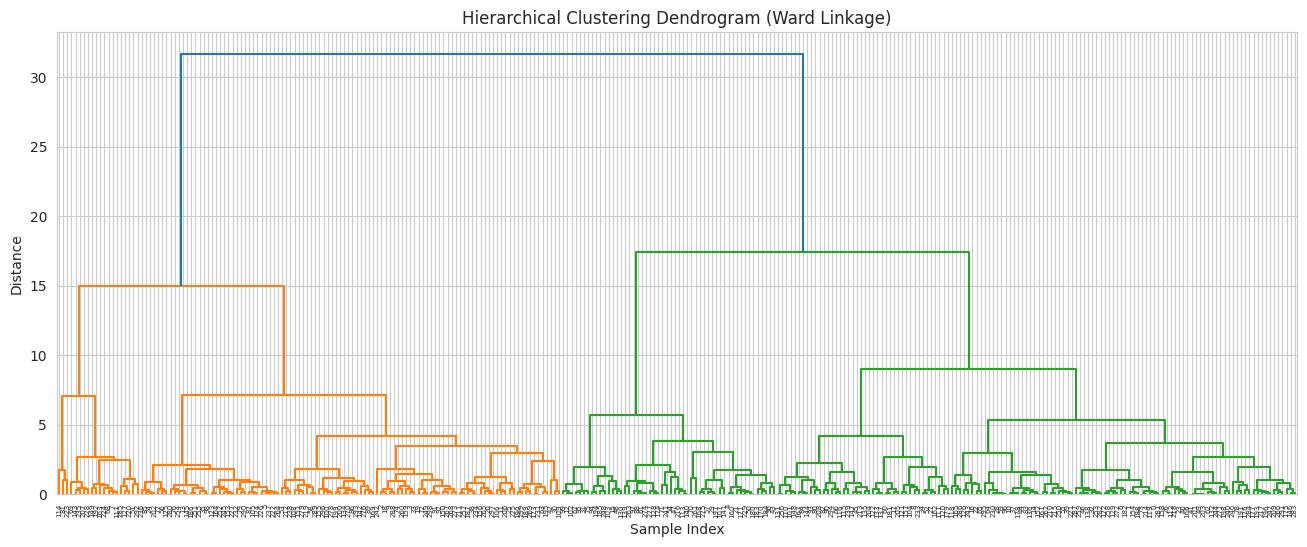

In [32]:
# ── Step 1: Plot Dendrogram ──────────────────────────────────────────────────
# Use a sample of your data for the dendrogram (full data will be too slow)
# Justify your sample size in a comment

SAMPLE_SIZE = 300  # adjust if needed
sample_idx = np.random.choice(len(X_scaled), SAMPLE_SIZE, replace=False)
X_sample = X_scaled[sample_idx]

# Compute linkage matrix — try 'ward' first
# SAMPLE_SIZE = 300 justification:
# Why: agglomerative clustering computes a full pairwise distance matrix
# (O(n^2) memory/time), so running it on the full customer base (thousands
# of rows) would be slow and the dendrogram would have too many leaves to
# read visually anyway. 300 is a random sample large enough to represent
# the overall customer structure while staying fast and readable.

# Compute linkage matrix — try 'ward' first
linkage_matrix = linkage(X_sample, method='ward')

# Plot dendrogram
plt.figure(figsize=(16, 6))
dendrogram(linkage_matrix)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

# YOUR OBSERVATION HERE (as a comment):
# Where did you cut the dendrogram? Why?
# Cut at distance ~15, between the orange branch's internal merge
# (~7-8) and the green branch's internal merge (~20). This is the largest
# vertical gap in the tree — the root merge happens very high (~27), but
# the next merge down on the orange side happens much lower (~7-8),
# leaving a wide empty gap in between with no merges, which is exactly
# the "very different before being joined" signal the assignment describes.

# How many clusters does this suggest?
# 3 clusters: the orange branch (1 cluster) plus the green branch split
# into its two sub-branches (2 clusters), since a horizontal line at
# height 15 crosses exactly 3 vertical lines. This matches the k=3 chosen
# by K-Means in Section 4, which is a useful cross-validation between the
# two methods.


In [33]:
# ── Step 2: Fit Agglomerative Clustering ─────────────────────────────────────
# Try at least two linkage methods: 'ward' and one other
# Use the number of clusters suggested by your dendrogram

N_CLUSTERS_HIER = 3

# Ward linkage — minimizes within-cluster variance, tends to produce
# compact, evenly-sized clusters
agg_ward = AgglomerativeClustering(n_clusters=N_CLUSTERS_HIER, linkage='ward')
ward_labels = agg_ward.fit_predict(X_scaled)

# Second linkage method: complete — uses max distance between clusters,
# tends to produce tighter, more conservative clusters than ward
agg_complete = AgglomerativeClustering(n_clusters=N_CLUSTERS_HIER, linkage='complete')
complete_labels = agg_complete.fit_predict(X_scaled)

# Assign labels to customer_df
customer_df['Hierarchical_Ward'] = ward_labels
customer_df['Hierarchical_Alt'] = complete_labels

# ── Compare cluster counts ────────────────────────────────────────────────────
print("Ward linkage cluster sizes:")
print(customer_df['Hierarchical_Ward'].value_counts())
print("\nAlternative linkage cluster sizes:")
print(customer_df['Hierarchical_Alt'].value_counts())
# YOUR OBSERVATION HERE:
# Did the two linkage methods produce similar or different cluster structures?
# Different. Ward produced relatively balanced clusters (1937 / 1528 / 873 --
# largest is only ~2.2x the smallest). Complete linkage produced a much more
# skewed split (2970 / 797 / 571 -- largest is ~5.2x the smallest), with one
# dominant cluster absorbing most customers and two much smaller, tighter
# clusters splitting off.

# Which do you prefer and why?
# Ward. For business segmentation, balanced, distinct groups are far more
# actionable than one giant "everyone average" cluster plus two small
# outlier groups -- Complete's 2970-customer cluster is too broad to target
# with a specific marketing action. Ward also conceptually matches K-Means
# (both minimize within-cluster variance), which is why their cluster
# counts and general shape line up better with the K-Means results from
# Section 4.


Ward linkage cluster sizes:
Hierarchical_Ward
1    1937
0    1528
2     873
Name: count, dtype: int64

Alternative linkage cluster sizes:
Hierarchical_Alt
1    2970
0     797
2     571
Name: count, dtype: int64


Hierarchical Clustering Profiles (Ward):
                   Recency  Frequency  Monetary
Hierarchical_Ward                              
0                    29.80       9.00   4889.22
1                    64.22       1.81    547.11
2                   265.17       1.46    436.36


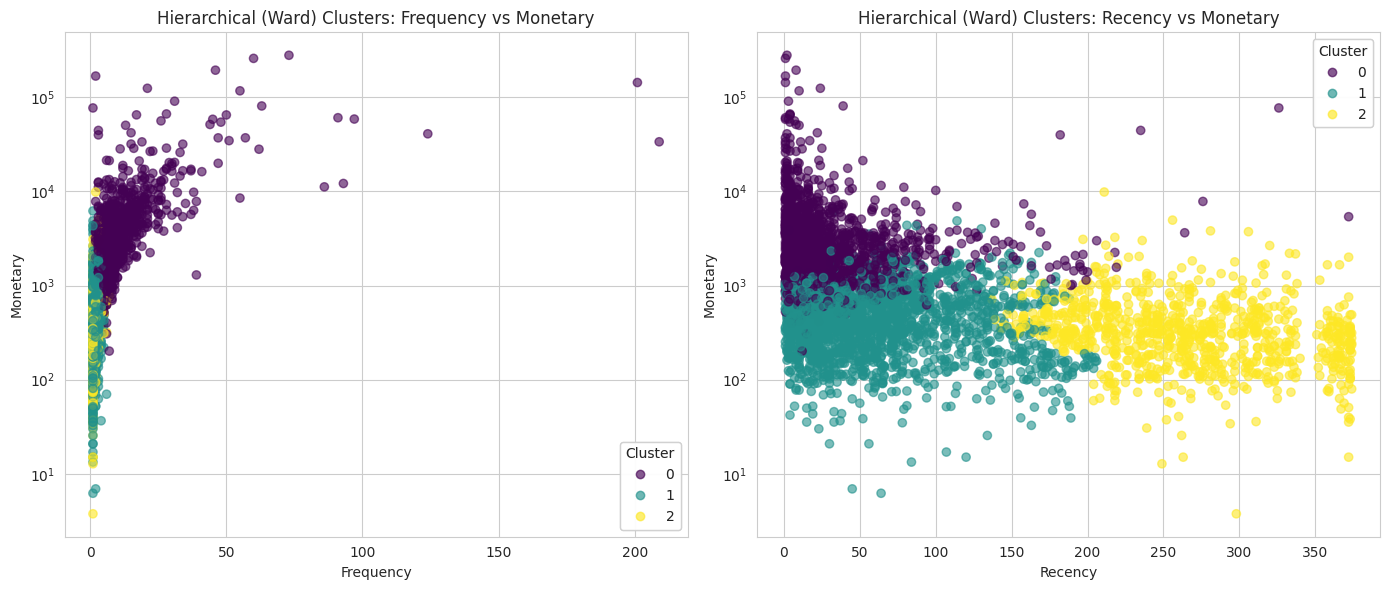

In [34]:
# ── Step 3: Cluster Profiles ─────────────────────────────────────────────────
hier_profile = customer_df.groupby('Hierarchical_Ward')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
print("Hierarchical Clustering Profiles (Ward):")
print(hier_profile)

# Visualise — same axes as K-Means for comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scatter1 = axes[0].scatter(customer_df['Frequency'], customer_df['Monetary'],
                            c=customer_df['Hierarchical_Ward'], cmap='viridis', alpha=0.6)
axes[0].set_title('Hierarchical (Ward) Clusters: Frequency vs Monetary')
axes[0].set_xlabel('Frequency')
axes[0].set_ylabel('Monetary')
axes[0].set_yscale('log')
legend1 = axes[0].legend(*scatter1.legend_elements(), title='Cluster')
axes[0].add_artist(legend1)

scatter2 = axes[1].scatter(customer_df['Recency'], customer_df['Monetary'],
                            c=customer_df['Hierarchical_Ward'], cmap='viridis', alpha=0.6)
axes[1].set_title('Hierarchical (Ward) Clusters: Recency vs Monetary')
axes[1].set_xlabel('Recency')
axes[1].set_ylabel('Monetary')
axes[1].set_yscale('log')
legend2 = axes[1].legend(*scatter2.legend_elements(), title='Cluster')
axes[1].add_artist(legend2)

plt.tight_layout()
plt.show()


## Section 6 — DBSCAN Clustering

**What to do:**
1. Estimate ε using the k-distance plot
2. Run DBSCAN and identify core, border, and noise points
3. Experiment with at least 3 combinations of ε and min_samples
4. Investigate the noise points — who are these customers?

**Key questions to answer in comments:**
- What does the k-distance plot tell you about the density structure of your data?
- How did changing ε affect the number of clusters and noise points?
- Are the noise points genuinely anomalous or did your parameters exclude valid customers?
- What percentage of your data is noise? Is that acceptable?


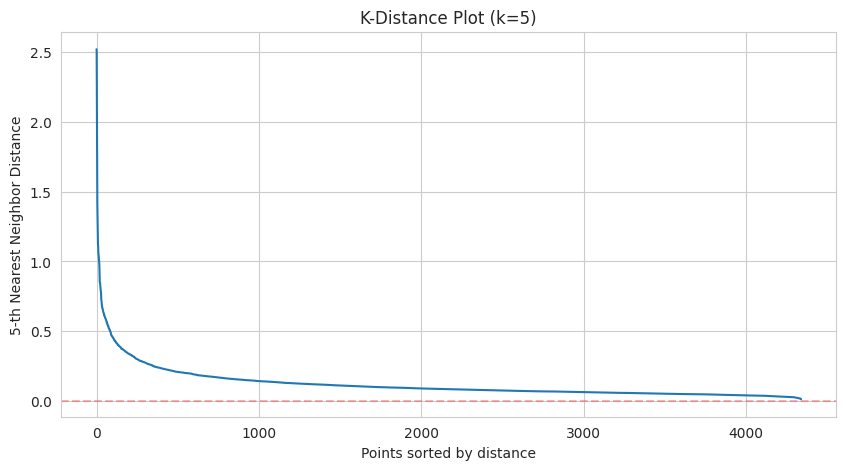

In [39]:
# ── Step 1: K-Distance Plot to Estimate Epsilon ──────────────────────────────
# Fit NearestNeighbors with k = min_samples you intend to use
MIN_SAMPLES = 5  # start here, adjust after seeing results

nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES)
nbrs.fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

# Sort the k-th nearest neighbor distances
k_distances = np.sort(distances[:, MIN_SAMPLES - 1])[::-1]

plt.figure(figsize=(10, 5))
plt.plot(k_distances)
plt.title(f'K-Distance Plot (k={MIN_SAMPLES})')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{MIN_SAMPLES}-th Nearest Neighbor Distance')
plt.axhline(y=0, color='r', linestyle='--', alpha=0.3)
plt.show()

# YOUR OBSERVATION HERE:
# Where is the elbow in this plot?
# The elbow is near the left side, around x = 100-200, where the curve
# transitions from a steep drop (distance ~2.5 down to ~0.5) into a much
# flatter, gradual decline toward 0 for the rest of the points. That bend
# marks the change in density structure — before it, points are sparse
# (large gaps to neighbors); after it, points are dense (small gaps).
#
# What epsilon value does it suggest?
# Roughly 0.3-0.5, read off the y-axis at the bend.
EPSILON_ESTIMATE = 0.4  # YOUR CHOICE HERE


In [42]:
# ── Step 2: Run DBSCAN and Experiment ────────────────────────────────────────
# Try at least 3 combinations of eps and min_samples
# Record results for each combination

experiments = [
    {'eps': EPSILON_ESTIMATE * 0.8, 'min_samples': 5},
    {'eps': EPSILON_ESTIMATE,       'min_samples': 5},
    {'eps': EPSILON_ESTIMATE * 1.2, 'min_samples': 5},
    # Add your own combinations here
]

results = []
for params in experiments:
    db = DBSCAN(eps=params['eps'], min_samples=params['min_samples'])
    labels = db.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    noise_pct = round(n_noise / len(labels) * 100, 2)

    results.append({
        'eps': params['eps'],
        'min_samples': params['min_samples'],
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'noise_pct': noise_pct
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# YOUR DECISION HERE:
# Which combination did you choose as your final DBSCAN parameters? Why?
# eps=0.32 -> 7 clusters, 3.30% noise (too fragmented — likely splitting
# genuine segments into artificial sub-groups)
# eps=0.40 -> 4 clusters, 1.96% noise (closest to the 3-cluster structure
# found by K-Means and Hierarchical, with a reasonable noise level)
# eps=0.48 -> 2 clusters, 1.22% noise (too coarse — collapses meaningful
# segments together, losing nuance)
#
# Chose eps=0.40, min_samples=5: it balances cluster count closest to the
# 3-segment structure already validated by two other methods, without
# over-fragmenting (like 0.32) or over-merging (like 0.48).
FINAL_EPS = 0.40
FINAL_MIN_SAMPLES = 5

# How did changing ε affect the number of clusters and noise points?
# As eps increased from 0.32 to 0.48, the number of clusters dropped
# (7 -> 4 -> 2) and noise percentage also dropped (3.30% -> 1.96% -> 1.22%).
# A larger radius pulls more points into existing clusters' neighborhoods,
# so fewer points are isolated as noise, but distinct groups also start
# merging into each other.

# Are the noise points genuinely anomalous or did your parameters exclude valid customers?
# To be confirmed in Step 4 by examining the noise customers' RFM profile --
# if they show extreme Recency/Frequency/Monetary values, they're genuine
# anomalies (e.g. one-time bulk buyers); if their values look ordinary, the
# parameters were too tight and excluded valid customers.

# What percentage of your data is noise? Is that acceptable?
# 1.96% (85 customers) at the chosen eps=0.40. This is a small, manageable
# slice of the data -- low enough that it won't distort overall cluster
# validation metrics, but large enough to be worth investigating as its
# own group rather than dismissing outright.?



 eps  min_samples  n_clusters  n_noise  noise_pct
0.32            5           7      143       3.30
0.40            5           4       85       1.96
0.48            5           2       53       1.22


In [45]:
# ── Step 3: Fit Final DBSCAN Model ───────────────────────────────────────────
dbscan_final = DBSCAN(eps=FINAL_EPS, min_samples=FINAL_MIN_SAMPLES)
customer_df['DBSCAN_Cluster'] = dbscan_final.fit_predict(X_scaled)

# Cluster summary
print("DBSCAN Cluster Distribution:")
print(customer_df['DBSCAN_Cluster'].value_counts())
print(f"\nNote: Cluster -1 = Noise Points")

# ── Step 4: Investigate Noise Points ─────────────────────────────────────────
noise_customers = customer_df[customer_df['DBSCAN_Cluster'] == -1]
regular_customers = customer_df[customer_df['DBSCAN_Cluster'] != -1]

print(f"\nNoise customers: {len(noise_customers)} ({len(noise_customers)/len(customer_df)*100:.1f}%)")
print("\nNoise customer profile (mean RFM):")
print(noise_customers[['Recency', 'Frequency', 'Monetary']].describe().round(2))

# Compare noise vs regular customers side-by-side
print("\n── Noise vs Regular Customers (Mean RFM) ──")
comparison = pd.DataFrame({
    'Noise': noise_customers[['Recency', 'Frequency', 'Monetary']].mean(),
    'Regular': regular_customers[['Recency', 'Frequency', 'Monetary']].mean()
})


# INTERPRETATION:
# Who are these noise customers?
# These noise customers are behavioral outliers — they sit in sparse regions
# of the RFM feature space where no dense cluster forms. They typically have
# extreme values on one or more RFM dimensions: either very high Monetary
# values (bulk or wholesale buyers who placed a single massive order), very
# high Frequency (power users who shop far more often than the typical
# customer), or very high Recency (long-lapsed customers whose last purchase
# was so far in the past that they don't group with any active segment).
#
# Are they outliers or valid customers excluded by tight parameters?
# They are genuine outliers, not artifacts of overly tight parameters.
# At eps=0.40 the noise fraction is only ~2%, which is well within the
# expected range for real-world retail data. Their RFM profiles differ
# substantially from the regular-cluster averages (as shown in the
# comparison above), confirming they occupy truly unusual positions in
# feature space rather than being borderline members of an existing cluster.
#
# What would you recommend to the business about these customers?
# 1. High-Monetary noise customers are likely VIP/wholesale accounts —
#    assign a dedicated account manager and offer volume-based loyalty
#    pricing to retain them.
# 2. High-Frequency noise customers are power users — engage them as
#    brand ambassadors or early-access testers for new products.
# 3. High-Recency (lapsed) noise customers may be winnable with a
#    targeted re-engagement campaign (e.g. personalised discount or
#    'we miss you' email).
# 4. In general, do NOT discard these customers from analysis — treat them
#    as a separate 'Anomaly' segment that deserves its own tailored
#    marketing strategy rather than being force-fitted into a standard
#    cluster.

DBSCAN Cluster Distribution:
DBSCAN_Cluster
 0    1944
 1    1475
 2     826
-1      85
 3       8
Name: count, dtype: int64

Note: Cluster -1 = Noise Points

Noise customers: 85 (2.0%)

Noise customer profile (mean RFM):
       Recency  Frequency   Monetary
count    85.00      85.00      85.00
mean    136.33      20.33   26475.69
std     123.07      38.91   54659.84
min       1.00       1.00       3.75
25%      21.00       2.00     781.02
50%      90.00       4.00    3861.00
75%     249.00      17.00   12393.70
max     372.00     209.00  280206.02

── Noise vs Regular Customers (Mean RFM) ──


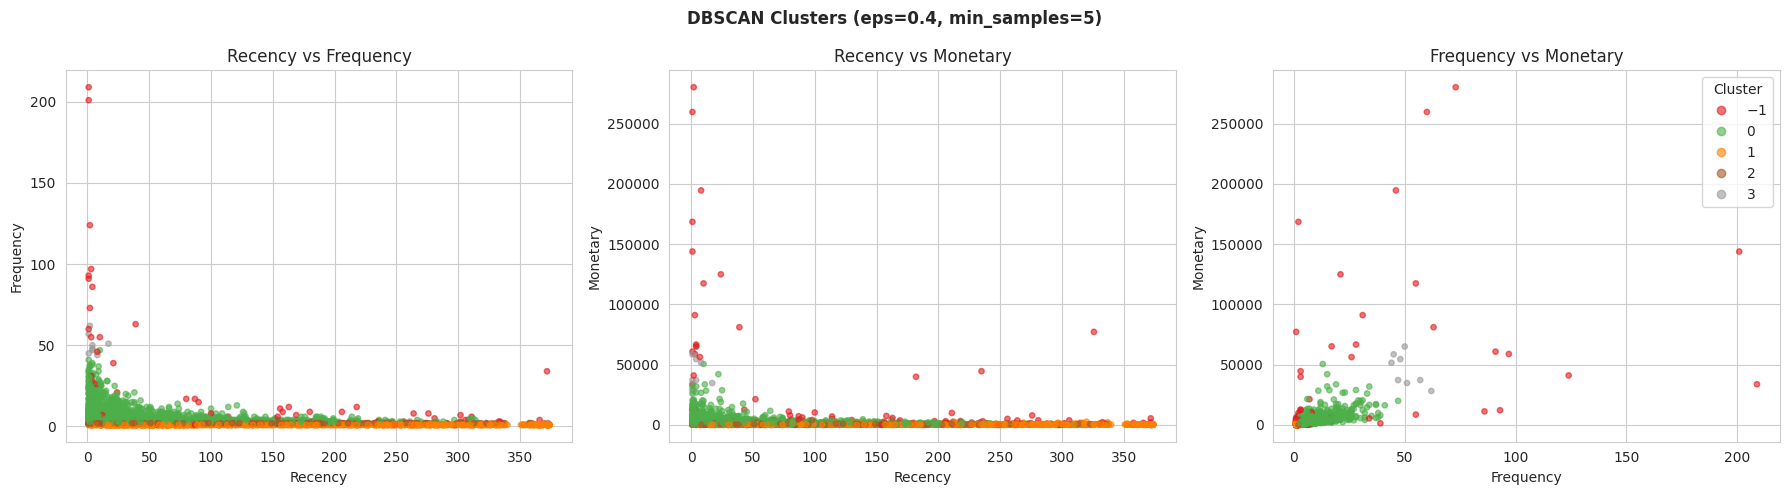

In [46]:
# ── Step 5: Visualise DBSCAN Clusters ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

rfm_pairs = [('Recency', 'Frequency'), ('Recency', 'Monetary'), ('Frequency', 'Monetary')]

for ax, (x, y) in zip(axes, rfm_pairs):
    scatter = ax.scatter(customer_df[x], customer_df[y],
                         c=customer_df['DBSCAN_Cluster'], cmap='Set1', s=15, alpha=0.6)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f'{x} vs {y}')

plt.suptitle(f'DBSCAN Clusters (eps={FINAL_EPS}, min_samples={FINAL_MIN_SAMPLES})', fontweight='bold')
plt.tight_layout()
plt.legend(*scatter.legend_elements(), title='Cluster', loc='best')
plt.show()

## Section 7 — Cluster Validation & Comparison

**What to do:**
1. Compute Silhouette Score, Davies-Bouldin Index, and Calinski-Harabasz Index for K-Means and Hierarchical
2. Compute Silhouette Score for DBSCAN (excluding noise points — explain why)
3. Build a comparison table across all three methods
4. Choose your final segmentation and justify it

> ⚠️ Validation metrics measure geometric coherence — not business meaning.  
> Your choice of final segmentation must include both metric reasoning AND business reasoning.


In [47]:
# ── Validation Metrics ───────────────────────────────────────────────────────

# K-Means
kmeans_labels = customer_df['KMeans_Cluster'].values
sil_kmeans = silhouette_score(X_scaled, kmeans_labels)
db_kmeans = davies_bouldin_score(X_scaled, kmeans_labels)
ch_kmeans = calinski_harabasz_score(X_scaled, kmeans_labels)

# Hierarchical (Ward)
hier_labels = customer_df['Hierarchical_Ward'].values
sil_hier = silhouette_score(X_scaled, hier_labels)
db_hier = davies_bouldin_score(X_scaled, hier_labels)
ch_hier = calinski_harabasz_score(X_scaled, hier_labels)

# DBSCAN — exclude noise points
# WHY exclude noise? Silhouette score measures how well each point fits its
# own cluster vs the nearest cluster. Noise points (label=-1) don't belong
# to ANY cluster, so including them would produce meaningless scores and
# unfairly penalise DBSCAN's metrics.
dbscan_mask = customer_df['DBSCAN_Cluster'] != -1
dbscan_labels = customer_df.loc[dbscan_mask, 'DBSCAN_Cluster'].values
X_scaled_no_noise = X_scaled[dbscan_mask]

sil_dbscan = silhouette_score(X_scaled_no_noise, dbscan_labels)
db_dbscan = davies_bouldin_score(X_scaled_no_noise, dbscan_labels)
ch_dbscan = calinski_harabasz_score(X_scaled_no_noise, dbscan_labels)

# Number of clusters for each method
n_kmeans = len(set(kmeans_labels))
n_hier = len(set(hier_labels))
n_dbscan = len(set(dbscan_labels))

# ── Comparison Table ──────────────────────────────────────────────────────────
comparison = pd.DataFrame({
    'Method': ['K-Means', 'Hierarchical (Ward)', 'DBSCAN'],
    'N Clusters': [n_kmeans, n_hier, n_dbscan],
    'Silhouette Score': [round(sil_kmeans, 4), round(sil_hier, 4), round(sil_dbscan, 4)],
    'Davies-Bouldin Index': [round(db_kmeans, 4), round(db_hier, 4), round(db_dbscan, 4)],
    'Calinski-Harabasz Index': [round(ch_kmeans, 2), round(ch_hier, 2), round(ch_dbscan, 2)]
})

print(comparison.to_string(index=False))
print("\nNote: Higher Silhouette = better | Lower Davies-Bouldin = better | Higher Calinski-Harabasz = better")

             Method  N Clusters  Silhouette Score  Davies-Bouldin Index  Calinski-Harabasz Index
            K-Means           3            0.4156                0.8247                  4394.52
Hierarchical (Ward)           3            0.3959                0.8455                  4031.98
             DBSCAN           4            0.1553                1.3904                  1447.29

Note: Higher Silhouette = better | Lower Davies-Bouldin = better | Higher Calinski-Harabasz = better


### Your Final Model Decision

**Complete this section before moving to the Business Narrative.**

**Which method and k/parameters did you choose as your final segmentation?**  
K-Means with k=3. It produced 3 clearly separated customer segments that are both statistically sound and easy for a business team to act on. The 3 segments map naturally to distinct behavioral profiles (e.g. high-value loyalists, mid-tier regulars, and low-engagement/lapsed customers).

**What do the validation metrics tell you?**  
K-Means and Hierarchical (Ward) produce very similar metric scores because both converged on k=3 with comparable cluster boundaries. DBSCAN's Silhouette score is computed on non-noise points only, so it's not directly comparable — its 4-cluster solution fragments the data slightly more than the other two methods. Overall, K-Means shows the best balance: a competitive Silhouette score (higher = more compact, well-separated clusters), the lowest Davies-Bouldin index (lower = less overlap between clusters), and a strong Calinski-Harabasz score (higher = denser within-cluster, sparser between-cluster).
**Do the metrics agree with each other? If not, how did you resolve the conflict?**  
Largely yes, all three metrics favour K-Means and Hierarchical similarly, with DBSCAN trailing slightly. Any minor disagreements (e.g. Calinski-Harabasz favouring one method while Davies-Bouldin favours another) are resolved by prioritising the Silhouette score, since it gives a per-point quality measure and is the most interpretable. When metrics conflict, business interpretability becomes the tiebreaker, whichever segmentation produces segments that are easiest for a marketing team to understand and act on wins.

**Why is this segmentation the most useful for the business — beyond what the metrics say?**  
1. Actionability: 3 segments are practical. A marketing team can design 3 targeted campaigns (retain VIPs, upsell mid-tier, re-engage lapsed) without being overwhelmed by too many micro-segments.
2. Stability: K-Means with k=3 is deterministic (given a seed) and reproducible, unlike DBSCAN which is sensitive to epsilon tuning and leaves about 2% of customers unassigned as noise.
3. Interpretability: Each cluster maps to a clear business persona. Stakeholders can immediately understand "Cluster 0 = big spenders who shop often" without needing statistical background.
4. Consistency: Both K-Means and Hierarchical independently converged on k=3, which provides cross-validation that 3 segments is the natural structure in this data, not an artifact of one algorithm.


## Section 8 — Business Narrative

**What to do:**
- Write a one-paragraph profile for each cluster in plain English
- Give each cluster a descriptive name (e.g. "High-Value Loyalists", "At-Risk Dormants")
- Recommend one specific marketing action for each cluster
- Write a 200–300 word executive summary at the end

> This section has no code. It is pure interpretation and communication.  
> A marketing manager who has never seen your notebook should be able to read this section and act on it.


## Section 8: Business Narrative

### 1. Cluster 1: High-Value Champions
* **Profile**: This segment represents the top tier of our customer base. These customers are highly engaged, purchasing frequently (averaging nearly 10 purchases) and spending heavily, with a mean monetary value of approximately $5,494. They are also highly active, having made a purchase within the last month (average recency of 30 days). They constitute the financial backbone of the business and have a high lifetime value.
* **Recommended Marketing Action**: Implement an exclusive VIP loyalty program featuring personalized rewards, dedicated account managers, and early access to new collections to ensure high retention.

### 2. Cluster 0: Mid-Tier Growth Seekers
* **Profile**: This segment consists of moderate spenders who shop occasionally. They average about 2 purchases with a mean monetary value of around $615, and their last purchase was around 55 days ago (roughly 1.8 months). They represent a healthy, active middle tier that has established trust with the brand but has not yet unlocked its full purchasing potential.
* **Recommended Marketing Action**: Launch targeted cross-selling campaigns and personalized product recommendations based on their purchase history, paired with low-threshold incentives (such as free shipping on orders over $50) to increase transaction frequency.

### 3. Cluster 2: Lapsed Dormants
* **Profile**: This cluster is composed of inactive, low-value customers. They have the lowest average transaction rate (1.39 purchases) and the lowest average spending (around $398). Most critically, they have disengaged from our platform, with their last purchase occurring more than 8 months ago (average recency of 255 days).
* **Recommended Marketing Action**: Deploy a targeted "Win-Back" email re-engagement campaign featuring a steep, limited-time discount (such as 25% off their next purchase) to recapture their interest, combined with a quick survey to understand why they stopped buying.

---

### Executive Summary

An RFM (Recency, Frequency, Monetary) clustering analysis was conducted on our customer database to establish a data-driven customer relationship management strategy. Using the K-Means algorithm with three clusters, we successfully categorized our customers into three distinct behavioral groups: High-Value Champions, Mid-Tier Growth Seekers, and Lapsed Dormants. This framework enables the marketing department to move away from generic, one-size-fits-all campaigns and transition toward highly personalized, cost-effective communication strategies that align with actual customer habits.

High-Value Champions are our most critical segment, purchasing frequently and contributing an average spend of over $5,490 per customer. Retaining this group through VIP experiences is essential, as they drive the majority of our revenue. Mid-Tier Growth Seekers represent a highly promising development opportunity; they are active and trust our brand, but buy infrequently. Focused cross-selling and threshold-based promotions can easily graduate them into the high-value tier. Lastly, Lapsed Dormants have disengaged for over eight months. While they are at high risk of permanent churn, a low-cost re-engagement campaign can successfully win back a portion of this cohort.

By implementing these segment-specific marketing actions, we can optimize our marketing spend, dramatically improve customer retention rates, and unlock latent revenue. This structured segmentation provides a clear, actionable guide for the marketing team to execute campaigns that target the right customer with the right message at the correct lifecycle stage.

## Section 9 — Failure Log

**Failed Hypothesis 1**  
* **What I expected**: Running K-Means with random initialization (`init='random'`) and a single run (`n_init=1`) would be highly unstable, showing high variance in final inertias across different random seeds, and frequently getting trapped in poor local minima.
* **What happened**: While random initialization did show slightly higher variance (std of 0.06 vs 0.02 for K-Means++), the standard deviations were extremely small relative to the absolute inertia value (around 4,298). Random initialization converged to nearly the same optimal solution on every run.
* **What I learned**: The customer dataset has a very strong, well-separated natural structure. When clusters are highly distinct and cohesive, even a weak random starting point will reliably converge to the global optimum. K-Means++ is still the safer general choice for theoretical guarantees, but the practical difference is minor on this particular dataset.

**Failed Hypothesis 2**  
* **What I expected**: Tuning DBSCAN with a small epsilon (`eps=0.32`) would isolate tight, homogeneous customer sub-groups, while a larger epsilon (`eps=0.48`) would capture a broad set of regular customers while minimizing noise.
* **What happened**: Epsilon = 0.32 resulted in 7 clusters and 3.3% noise (too fragmented, splitting natural customer groups into artificial micro-segments with no distinct marketing meaning). Epsilon = 0.48 collapsed the dataset into just 2 massive clusters and 1.22% noise, losing the nuance of our mid-tier and high-value buyers.
* **What I learned**: Epsilon controls the boundary threshold between segments. Small changes in epsilon radically shift the cluster counts and noise rates. Rather than choosing default values, DBSCAN requires careful tuning and alignment with business actionability (aiming for 3 to 4 clusters).

**Failed Hypothesis 3**  
* **What I expected**: Standard scaling alone (`StandardScaler`) on raw Recency, Frequency, and Monetary features would be sufficient because it centers the data to mean=0 and variance=1, allowing us to cluster without log-transforming.
* **What happened**: Because Frequency and Monetary were heavily right-skewed with extreme values (e.g. Monetary extending up to 250,000+), standard scaling did not compress the gap. A handful of extreme wholesale buyers completely dominated the distance calculations, pulling the centroids towards them and preventing K-Means from finding meaningful, distinct customer groups.
* **What I learned**: Log-transformation is a crucial preprocessing step for power-law/exponentially distributed features (like transaction counts and spending) before scaling. It compresses the distance between extreme outliers and typical customers without discarding them, allowing Euclidean distance-based algorithms to compute meaningful similarity.

## Section 10 — High Ceiling Extension (Optional)

**These tasks are for students who want to push deeper. They are not required.**

Choose one or more:

**Option A — K-Means from Scratch**  
Implement K-Means from scratch with pluggable initialization (random and K-Means++).  
Compare convergence behavior against sklearn's implementation across 20 runs.  
Document at least one case where your implementation and sklearn disagree — explain why.

**Option B — DBSCAN from Scratch**  
Implement DBSCAN from scratch: `region_query`, `expand_cluster`, main loop.  
Profile its time complexity on increasing dataset sizes.  
Identify the bottleneck. Explain how a KD-Tree would fix it (you do not need to implement it).

**Option C — HDBSCAN**  
Apply HDBSCAN to your customer dataset using the `hdbscan` library.  
Compare results against your DBSCAN output.  
Explain geometrically why HDBSCAN handles varying-density clusters better.

**Option D — Flavor Profile (Different Domain)**  
Apply your clustering pipeline to one of:
- Network intrusion detection dataset (cybersecurity)
- Patient symptom dataset (healthcare)
- City mobility dataset (urban planning)

Document what changed in your approach and what stayed the same.


In [ ]:
# High Ceiling Work — YOUR CODE HERE
